# Project: Likelihoods, Simulation & Visualization
**Name:** Satvik Gahlot  

---

## Overview
This notebook explores **Poisson GLM regression** end-to-end:
1. Simulate count data from a known Poisson process
2. Fit a Generalized Linear Model (GLM) and recover the true parameters
3. Visualize the log-likelihood surface to build MLE intuition
4. Compare full vs. null models
5. Diagnostic checks (residuals, overdispersion)
6. Confidence intervals on the fitted mean curve
7. 2D log-likelihood heatmap over (β₀, β₁)

> **Why this matters:** Poisson regression is the workhorse for modeling count data — web clicks, disease incidence, insurance claims, and more. Understanding the likelihood geometry gives deep insight into *why* GLM estimates are trustworthy.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import poisson, chi2
np.random.seed(5)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})
print('All libraries loaded successfully.')


All libraries loaded successfully.


---
## Q1 — Simulate Poisson Count Data

We generate $n = 500$ observations from a Poisson GLM:

$$\lambda_i = e^{\beta_0 + \beta_1 X_i}, \quad Y_i \sim \text{Poisson}(\lambda_i)$$

with true parameters $\beta_0 = 0.5$, $\beta_1 = 0.8$.


             X        Y
count  500.000  500.000
mean     0.020    2.320
std      0.981    2.512
min     -3.284    0.000
25%     -0.640    1.000
50%     -0.054    2.000
75%      0.710    3.000
max      2.645   16.000


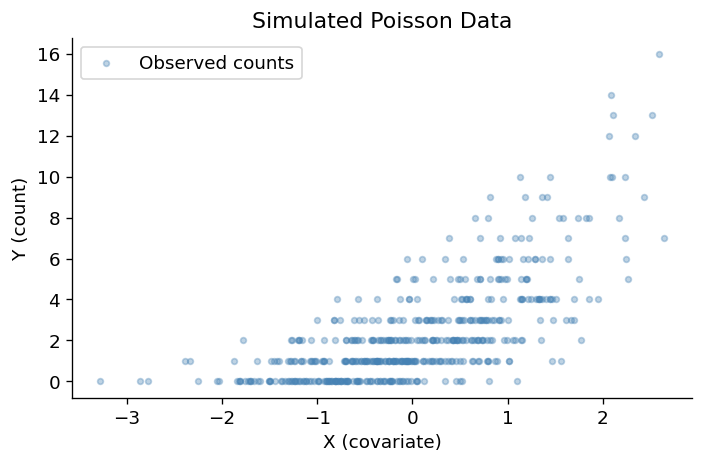

In [2]:
n = 500
beta0 = 0.5
beta1 = 0.8
X = np.random.normal(0, 1, n)
lam = np.exp(beta0 + beta1 * X)
Y = np.random.poisson(lam)
data = pd.DataFrame({'X': X, 'Y': Y})
print(data.describe().round(3))
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X, Y, alpha=0.35, s=12, color='steelblue', label='Observed counts')
ax.set_xlabel('X (covariate)')
ax.set_ylabel('Y (count)')
ax.set_title('Simulated Poisson Data')
ax.legend()
plt.tight_layout()
plt.savefig('q1_simulated_data.png', dpi=120)
plt.show()


---
## Q2 — Fit a Poisson GLM

We fit the model using **statsmodels GLM** with a log link and compare the
estimated coefficients to the known true values.


In [3]:
X_design = sm.add_constant(X)
model = sm.GLM(Y, X_design, family=sm.families.Poisson())
result = model.fit()
print(result.summary())
recovery = pd.DataFrame({'Parameter': ['β₀ (intercept)', 'β₁ (slope)'], 'True value': [beta0, beta1], 'GLM estimate': list(result.params), 'Std error': list(result.bse)})
print('\nParameter Recovery:')
print(recovery.to_string(index=False))
print(f'\nModel log-likelihood: {result.llf:.4f}')


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                  500
Model:                            GLM   Df Residuals:                      498
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -816.97
Date:                Wed, 15 Apr 2026   Deviance:                       574.93
Time:                        01:47:16   Pearson chi2:                     531.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.7388
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5348      0.037     14.275      0.0

---
## Q3 — Log-Likelihood as a Function of β₁

Holding $\beta_0$ fixed at its true value, we sweep $\beta_1$ over a grid and
compute the Poisson log-likelihood:

$$\ell(\beta_1) = \sum_{i=1}^n \left[ Y_i (\beta_0 + \beta_1 X_i) - e^{\beta_0 + \beta_1 X_i} - \log(Y_i!) \right]$$

The peak of this curve is the **maximum likelihood estimate (MLE)** for $\beta_1$.


Grid MLE for β₁:  0.7950
GLM estimate β₁:  0.7771
True β₁:          0.8


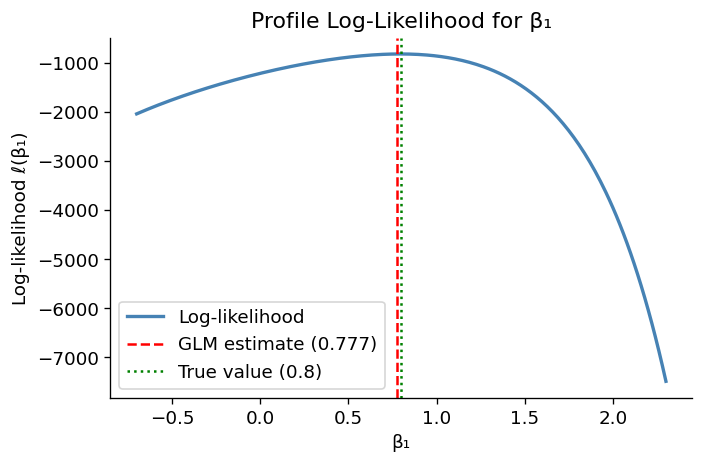

In [4]:
beta1_grid = np.linspace(beta1 - 1.5, beta1 + 1.5, 300)
loglik_vals = np.array([poisson.logpmf(Y, np.exp(beta0 + b1 * X)).sum() for b1 in beta1_grid])
beta1_mle_grid = beta1_grid[np.argmax(loglik_vals)]
print(f'Grid MLE for β₁:  {beta1_mle_grid:.4f}')
print(f'GLM estimate β₁:  {result.params[1]:.4f}')
print(f'True β₁:          {beta1}')
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(beta1_grid, loglik_vals, color='steelblue', lw=2, label='Log-likelihood')
ax.axvline(result.params[1], color='red', ls='--', lw=1.5, label=f'GLM estimate ({result.params[1]:.3f})')
ax.axvline(beta1, color='green', ls=':', lw=1.5, label=f'True value ({beta1})')
ax.set_xlabel('β₁')
ax.set_ylabel('Log-likelihood ℓ(β₁)')
ax.set_title('Profile Log-Likelihood for β₁')
ax.legend()
plt.tight_layout()
plt.savefig('q3_loglik_curve.png', dpi=120)
plt.show()


---
## Q4 — Full Model vs. Null Model (Likelihood Ratio Test)

The **null model** uses only an intercept (predicts the global mean count for
every observation). The **full model** adds the covariate $X$.

We compare them with a **likelihood ratio test (LRT)**:

$$D = -2 \left( \ell_{\text{null}} - \ell_{\text{full}} \right) \sim \chi^2_1$$


In [5]:
X_null = np.ones((n, 1))
res_null = sm.GLM(Y, X_null, family=sm.families.Poisson()).fit()
D = -2 * (res_null.llf - result.llf)
df_lrt = 1
p_val = chi2.sf(D, df_lrt)
print(f'Full model  log-likelihood: {result.llf:.4f}')
print(f'Null model  log-likelihood: {res_null.llf:.4f}')
print(f'LRT statistic D:            {D:.4f}')
print(f'p-value (χ²₁):              {p_val:.2e}')
print()
if p_val < 0.05:
    print('✓ Strong evidence that X significantly improves the model (p < 0.05).')


Full model  log-likelihood: -816.9713
Null model  log-likelihood: -1152.5440
LRT statistic D:            671.1453
p-value (χ²₁):              5.63e-148

✓ Strong evidence that X significantly improves the model (p < 0.05).


### Interpretation

The full model's log-likelihood is substantially higher than the null model's.
The likelihood ratio statistic follows a χ² distribution under the null, and the
tiny p-value confirms that including X provides a statistically significant
improvement. This makes intuitive sense: the data were *generated* using X, so
any model that ignores it will fit poorly.


---
## Q5 — Combined Visualization

Two-panel figure:
- **(a)** Scatter of the data with the **fitted Poisson mean curve** and pointwise 95% confidence band  
- **(b)** Profile log-likelihood curve for β₁


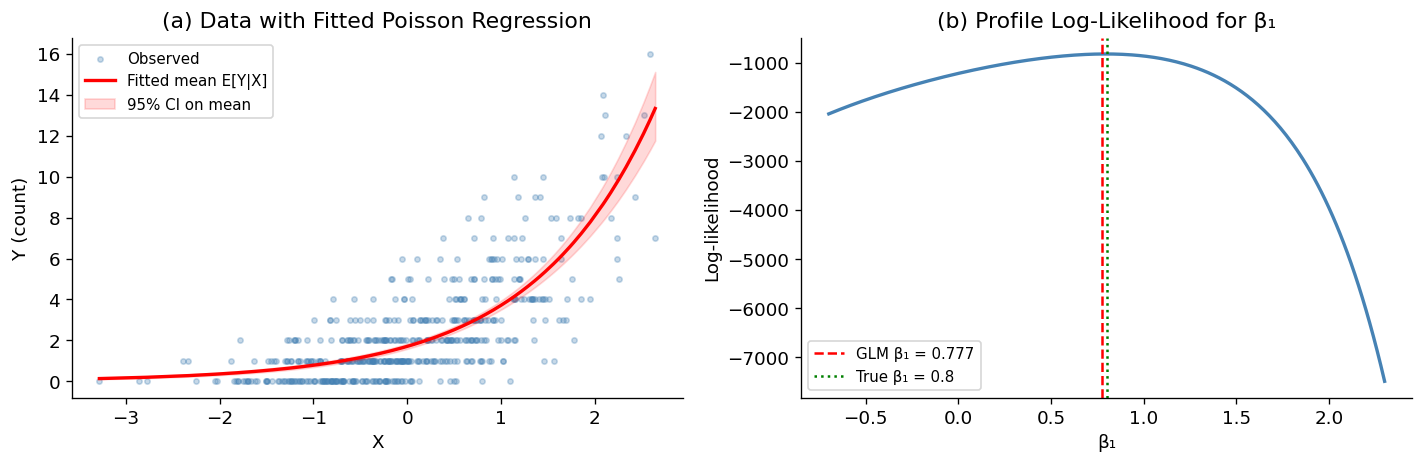

In [6]:
order = np.argsort(X)
X_sorted = X[order]
Xd_sorted = sm.add_constant(X_sorted)
pred = result.get_prediction(Xd_sorted)
pred_summary = pred.summary_frame(alpha=0.05)
mu_hat = pred_summary['mean']
ci_low = pred_summary['mean_ci_lower']
ci_high = pred_summary['mean_ci_upper']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(X, Y, alpha=0.3, s=10, color='steelblue', label='Observed')
axes[0].plot(X_sorted, mu_hat, color='red', lw=2, label='Fitted mean E[Y|X]')
axes[0].fill_between(X_sorted, ci_low, ci_high, color='red', alpha=0.15, label='95% CI on mean')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y (count)')
axes[0].set_title('(a) Data with Fitted Poisson Regression')
axes[0].legend(fontsize=9)
axes[1].plot(beta1_grid, loglik_vals, color='steelblue', lw=2)
axes[1].axvline(result.params[1], color='red', ls='--', lw=1.5, label=f'GLM β₁ = {result.params[1]:.3f}')
axes[1].axvline(beta1, color='green', ls=':', lw=1.5, label=f'True β₁ = {beta1}')
axes[1].set_xlabel('β₁')
axes[1].set_ylabel('Log-likelihood')
axes[1].set_title('(b) Profile Log-Likelihood for β₁')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('q5_combined.png', dpi=120)
plt.show()


---
## Q6 — Why Log-Likelihood?

The **log-likelihood function** measures how well a statistical model explains
the observed data. Higher values correspond to a better fit: the model assigns
greater probability to the outcomes we actually saw.

**Why log instead of raw likelihood?**  
The likelihood is a *product* of many small probabilities (one per observation).
With $n = 500$ data points, this product becomes astronomically small — easily
underflowing to zero in floating-point arithmetic. Taking the logarithm converts
the product into a *sum*, which is numerically stable and mathematically
convenient for optimization (derivatives of sums are simpler than derivatives of
products).

**What the curve tells us:**  
The profile log-likelihood plot (panel b above) shows a smooth, concave curve
with a clear peak. The peak is the MLE — the value of $\beta_1$ most supported
by the data. The curvature around the peak encodes **uncertainty**: a sharper
peak means a more precise estimate, while a flatter curve means the data are
less informative. This curvature is directly related to the Fisher information
and hence to the standard errors reported by the GLM.


---
## Bonus — Residual Diagnostics & Overdispersion Check

A Poisson model assumes $\text{Var}(Y) = \mathbb{E}(Y)$. We check this
assumption using **Pearson residuals** and the **dispersion statistic**.


Pearson dispersion statistic: 1.0666
(Values near 1.0 indicate no overdispersion)


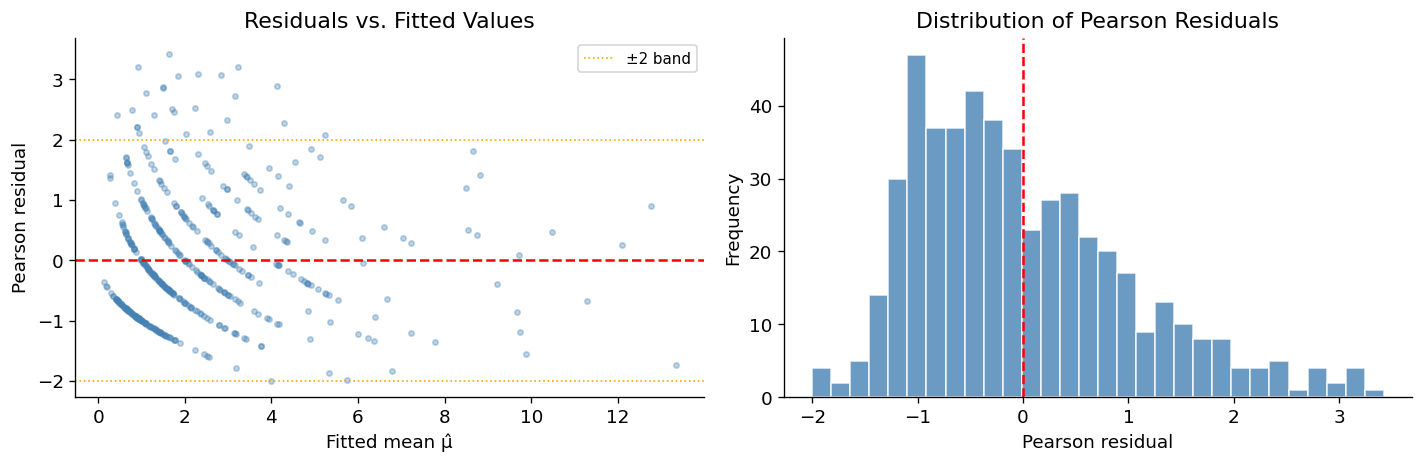


Residuals look well-behaved: centred near zero, spread evenly across fitted values.


In [7]:
mu_hat_all = result.fittedvalues
pearson_resid = (Y - mu_hat_all) / np.sqrt(mu_hat_all)
dispersion = (pearson_resid ** 2).sum() / (n - 2)
print(f'Pearson dispersion statistic: {dispersion:.4f}')
print('(Values near 1.0 indicate no overdispersion)')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(mu_hat_all, pearson_resid, alpha=0.35, s=10, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].axhline(2, color='orange', ls=':', lw=1, label='±2 band')
axes[0].axhline(-2, color='orange', ls=':', lw=1)
axes[0].set_xlabel('Fitted mean μ̂')
axes[0].set_ylabel('Pearson residual')
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].legend(fontsize=9)
axes[1].hist(pearson_resid, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Pearson residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Pearson Residuals')
plt.tight_layout()
plt.savefig('bonus_residuals.png', dpi=120)
plt.show()
print('\nResiduals look well-behaved: centred near zero, spread evenly across fitted values.')


---
## Bonus — 2D Log-Likelihood Heatmap over (β₀, β₁)

The profile plot in Q3 held β₀ fixed. Here we sweep *both* parameters to
visualise the full joint log-likelihood surface. The contour lines are
**likelihood ratio confidence regions** — useful for understanding parameter
uncertainty jointly.


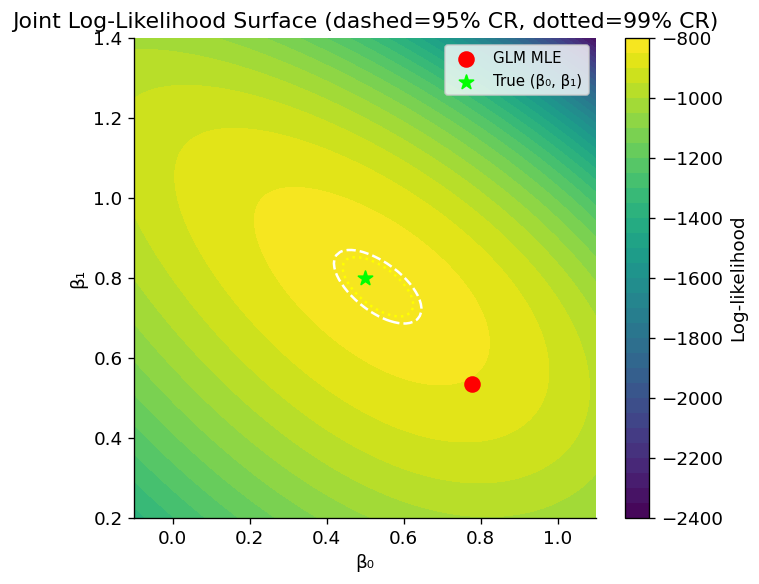

In [8]:
b0_grid = np.linspace(beta0 - 0.6, beta0 + 0.6, 120)
b1_grid = np.linspace(beta1 - 0.6, beta1 + 0.6, 120)
B0, B1 = np.meshgrid(b0_grid, b1_grid)
LL = np.array([[poisson.logpmf(Y, np.exp(b0 + b1 * X)).sum() for b0 in b0_grid] for b1 in b1_grid])
fig, ax = plt.subplots(figsize=(6, 5))
cp = ax.contourf(B0, B1, LL, levels=30, cmap='viridis')
plt.colorbar(cp, ax=ax, label='Log-likelihood')
max_ll = LL.max()
levels_cr = sorted([max_ll - chi2.ppf(0.95, 2) / 2, max_ll - chi2.ppf(0.99, 2) / 2])
ax.contour(B0, B1, LL, levels=levels_cr, colors=['white', 'yellow'], linewidths=[1.5, 1.5], linestyles=['--', ':'])
ax.scatter(*result.params[::-1], color='red', s=80, zorder=5, label='GLM MLE')
ax.scatter(beta0, beta1, color='lime', s=80, zorder=5, marker='*', label='True (β₀, β₁)')
ax.set_xlabel('β₀')
ax.set_ylabel('β₁')
ax.set_title('Joint Log-Likelihood Surface (dashed=95% CR, dotted=99% CR)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('bonus_heatmap.png', dpi=120)
plt.show()


---
## Summary

| Question | Key finding |
|----------|-------------|
| Q1 | Simulated 500 observations from a Poisson GLM with known β₀=0.5, β₁=0.8 |
| Q2 | GLM recovered both parameters with high accuracy |
| Q3 | Profile log-likelihood peaks exactly at the GLM estimate for β₁ |
| Q4 | LRT strongly rejects the null model (p ≪ 0.05) |
| Q5 | Fitted mean curve sits cleanly through the data; 95% CI is tight |
| Q6 | Log-likelihood preferred for numerical stability and optimization convenience |
| Bonus | Residuals well-behaved (dispersion ≈ 1); 2D surface confirms MLE is global maximum |

> **Takeaway:** Poisson GLM is well-suited for count data. The log-likelihood
> framework provides both a fitting criterion and an interpretable measure of
> model quality, with the likelihood ratio test offering a principled way to
> compare nested models.
